In [ ]:
import os
import random
import time
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")
SEED = 46

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())

Random seed: 46
PyTorch version: 2.13.0
CUDA available: False
MPS available: True


In [ ]:
DATA_DIR = "selected_500_species_dataset 2"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
TEST_DIR = os.path.join(DATA_DIR, "test")

TRAIN_CSV = os.path.join(DATA_DIR, "train_labels.csv")
VAL_CSV = os.path.join(DATA_DIR, "validation_labels.csv")
TEST_CSV = os.path.join(DATA_DIR, "test_labels.csv")

paths_to_check = {
    "Train directory": TRAIN_DIR,
    "Validation directory": VAL_DIR,
    "Test directory": TEST_DIR,
    "Train CSV": TRAIN_CSV,
    "Validation CSV": VAL_CSV,
    "Test CSV": TEST_CSV
}

for name, path in paths_to_check.items():
    print(f"{name}: {path}")
    print("Exists:", os.path.exists(path))
    print("-" * 50)

Train directory: selected_500_species_dataset 2/train
Exists: True
--------------------------------------------------
Validation directory: selected_500_species_dataset 2/val
Exists: True
--------------------------------------------------
Test directory: selected_500_species_dataset 2/test
Exists: True
--------------------------------------------------
Train CSV: selected_500_species_dataset 2/train_labels.csv
Exists: True
--------------------------------------------------
Validation CSV: selected_500_species_dataset 2/validation_labels.csv
Exists: True
--------------------------------------------------
Test CSV: selected_500_species_dataset 2/test_labels.csv
Exists: True
--------------------------------------------------


In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(val_df.head())
display(test_df.head())

Train shape: (20000, 2)
Validation shape: (5000, 2)
Test shape: (5000, 2)


,file_name,category_id
0,6ad1b07b-71db-456d-96cc-33b51a1b1ab1.jpg,1251
1,c72c31a4-08ff-4fea-abfc-c3a9b8b4a911.jpg,1251
2,db469428-2dda-43ce-a807-339adc0f1bae.jpg,1251
3,e0ec6e01-488a-49a9-a93c-7553733bf0ef.jpg,1251
4,07244222-a31e-4e2f-bc0c-73f13117976d.jpg,1251


,file_name,category_id
0,e986c7a6-904c-4b09-971a-d97707a4b816.jpg,1251
1,50d9c86a-8053-4bfc-944d-d74e4bb5b436.jpg,1251
2,35fe1495-a579-4a4b-900a-3dc56ed11826.jpg,1251
3,041b2d3f-a101-4ea7-86aa-3f9cd09e9f30.jpg,1251
4,4fe1bdfa-133a-4e46-a289-2296b78e7389.jpg,1251


,file_name,category_id
0,6ba17b04-5e1d-40d2-b60a-183676f2ad9b.jpg,5813
1,200b87d5-ad48-48e1-a3d3-a721f0c3ec23.jpg,4943
2,935c569d-6b96-465b-9fcf-9e0970500766.jpg,2630
3,73db5011-71ea-4026-b3df-3768b6adeb41.jpg,1405
4,bc419462-91cb-4523-bf18-ed079efb0da6.jpg,3768


In [ ]:
print("Train columns:", train_df.columns.tolist())
print("Validation columns:", val_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

print("Number of train classes:", train_df["category_id"].nunique())
print("Number of validation classes:", val_df["category_id"].nunique())
print("Number of test classes:", test_df["category_id"].nunique())

print("Train category sample:")
print(train_df["category_id"].head(10).tolist())

Train columns: ['file_name', 'category_id']
Validation columns: ['file_name', 'category_id']
Test columns: ['file_name', 'category_id']
Number of train classes: 500
Number of validation classes: 500
Number of test classes: 500
Train category sample:
[1251, 1251, 1251, 1251, 1251, 1251, 1251, 1251, 1251, 1251]


In [ ]:
all_categories = sorted(train_df["category_id"].unique())

category_to_index = {
    category_id: index
    for index, category_id in enumerate(all_categories)
}

index_to_category = {
    index: category_id
    for category_id, index in category_to_index.items()
}

train_df["label"] = train_df["category_id"].map(category_to_index)
val_df["label"] = val_df["category_id"].map(category_to_index)
test_df["label"] = test_df["category_id"].map(category_to_index)

print("Number of mapped classes:", len(category_to_index))
print("Mapped label range:",
      train_df["label"].min(),
      "to",
      train_df["label"].max())

display(train_df.head())

Number of mapped classes: 500
Mapped label range: 0 to 499


,file_name,category_id,label
0,6ad1b07b-71db-456d-96cc-33b51a1b1ab1.jpg,1251,60
1,c72c31a4-08ff-4fea-abfc-c3a9b8b4a911.jpg,1251,60
2,db469428-2dda-43ce-a807-339adc0f1bae.jpg,1251,60
3,e0ec6e01-488a-49a9-a93c-7553733bf0ef.jpg,1251,60
4,07244222-a31e-4e2f-bc0c-73f13117976d.jpg,1251,60


In [ ]:
train_categories = set(train_df["category_id"].unique())
val_categories = set(val_df["category_id"].unique())
test_categories = set(test_df["category_id"].unique())

print("Train and validation classes match:",
      train_categories == val_categories)

print("Train and test classes match:",
      train_categories == test_categories)

print("Missing labels in train:",
      train_df["label"].isna().sum())

print("Missing labels in validation:",
      val_df["label"].isna().sum())

print("Missing labels in test:",
      test_df["label"].isna().sum())

Train and validation classes match: True
Train and test classes match: True
Missing labels in train: 0
Missing labels in validation: 0
Missing labels in test: 0


In [ ]:
class SpeciesDataset(Dataset):
    def __init__(self, dataframe, image_dirs, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)

        if isinstance(image_dirs, str):
            image_dirs = [image_dirs]

        self.image_dirs = image_dirs
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        file_name = row["file_name"]

        image_path = None

        for image_dir in self.image_dirs:
            candidate_path = os.path.join(image_dir, file_name)

            if os.path.exists(candidate_path):
                image_path = candidate_path
                break

        if image_path is None:
            raise FileNotFoundError(
                f"Image not found in configured directories: {file_name}"
            )

        image = Image.open(image_path).convert("RGB")
        label = int(row["label"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [ ]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dataset = SpeciesDataset(
    dataframe=train_df,
    image_dirs=[
        "selected_500_species_dataset/train",
        "selected_500_species_dataset 2/train"
    ],
    transform=train_transform
)

val_dataset = SpeciesDataset(
    dataframe=val_df,
    image_dirs="selected_500_species_dataset 2/val",
    transform=eval_transform
)

test_dataset = SpeciesDataset(
    dataframe=test_df,
    image_dirs="selected_500_species_dataset 2/test",
    transform=eval_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 20000
Validation dataset: 5000
Test dataset: 5000


In [ ]:
sample_image, sample_label = train_dataset[0]

print("Image tensor shape:", sample_image.shape)
print("Mapped label:", sample_label)
print("Original category ID:", index_to_category[sample_label])

Image tensor shape: torch.Size([3, 224, 224])
Mapped label: 60
Original category ID: 1251


In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 625
Validation batches: 157
Test batches: 157


In [ ]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Label range:", labels.min().item(), "to", labels.max().item())

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Label range: 37 to 496


In [ ]:
NUM_CLASSES = 500

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = SimpleCNN(num_classes=NUM_CLASSES).to(device)

print("Using device:", device)
print(model)

Using device: mps
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   

In [ ]:
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    outputs = model(sample_images)

print("Input shape :", sample_images.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 500])


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

In [ ]:
NUM_EPOCHS = 10

train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_acc = 0.0

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_predictions

In [ ]:
for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step()

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_simple_cnn.pth"
        )

        print("Best CNN model saved.")


Epoch [1/10]
Train Loss : 6.0712
Train Acc  : 0.0083
Val Loss   : 5.7534
Val Acc    : 0.0128
Best CNN model saved.

Epoch [2/10]
Train Loss : 5.6941
Train Acc  : 0.0170
Val Loss   : 5.5185
Val Acc    : 0.0284
Best CNN model saved.

Epoch [3/10]
Train Loss : 5.4661
Train Acc  : 0.0290
Val Loss   : 5.3388
Val Acc    : 0.0384
Best CNN model saved.

Epoch [4/10]
Train Loss : 5.3004
Train Acc  : 0.0368
Val Loss   : 5.3112
Val Acc    : 0.0534
Best CNN model saved.

Epoch [5/10]
Train Loss : 5.1731
Train Acc  : 0.0495
Val Loss   : 5.1016
Val Acc    : 0.0612
Best CNN model saved.

Epoch [6/10]
Train Loss : 4.9650
Train Acc  : 0.0701
Val Loss   : 4.9948
Val Acc    : 0.0796
Best CNN model saved.

Epoch [7/10]
Train Loss : 4.8988
Train Acc  : 0.0757
Val Loss   : 4.9788
Val Acc    : 0.0806
Best CNN model saved.

Epoch [8/10]
Train Loss : 4.8759
Train Acc  : 0.0780
Val Loss   : 4.9578
Val Acc    : 0.0820
Best CNN model saved.

Epoch [9/10]
Train Loss : 4.8546
Train Acc  : 0.0786
Val Loss   : 4.924

In [ ]:
model.load_state_dict(
    torch.load(
        "best_simple_cnn.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

print("Best CNN model loaded successfully.")

Best CNN model loaded successfully.


In [ ]:
test_loss, test_acc, test_labels, test_preds = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Acc  : {test_acc:.4f}")

Test Loss : 4.9121
Test Acc  : 0.0880


In [ ]:
print(classification_report(
    test_labels,
    test_preds,
    labels=list(range(NUM_CLASSES)),
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        10
           1     0.0476    0.1000    0.0645        10
           2     0.0000    0.0000    0.0000        10
           3     0.0000    0.0000    0.0000        10
           4     0.0714    0.2000    0.1053        10
           5     0.0000    0.0000    0.0000        10
           6     0.0000    0.0000    0.0000        10
           7     0.0000    0.0000    0.0000        10
           8     0.0000    0.0000    0.0000        10
           9     0.0000    0.0000    0.0000        10
          10     0.0000    0.0000    0.0000        10
          11     0.0000    0.0000    0.0000        10
          12     0.0000    0.0000    0.0000        10
          13     0.0000    0.0000    0.0000        10
          14     0.0000    0.0000    0.0000        10
          15     0.0000    0.0000    0.0000        10
          16     0.1111    0.1000    0.1053        10
          17     0.1111    

In [ ]:
precision = precision_score(
    test_labels,
    test_preds,
    average="macro",
    zero_division=0
)

recall = recall_score(
    test_labels,
    test_preds,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    test_labels,
    test_preds,
    average="macro",
    zero_division=0
)

balanced_acc = balanced_accuracy_score(
    test_labels,
    test_preds
)

print(f"Test Accuracy      : {test_acc:.4f}")
print(f"Macro Precision    : {precision:.4f}")
print(f"Macro Recall       : {recall:.4f}")
print(f"Macro F1-score     : {macro_f1:.4f}")
print(f"Balanced Accuracy  : {balanced_acc:.4f}")

Test Accuracy      : 0.0880
Macro Precision    : 0.0756
Macro Recall       : 0.0880
Macro F1-score     : 0.0697
Balanced Accuracy  : 0.0880


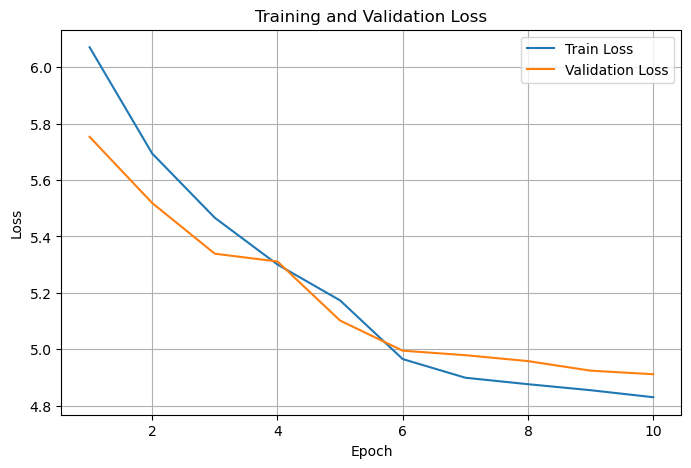

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

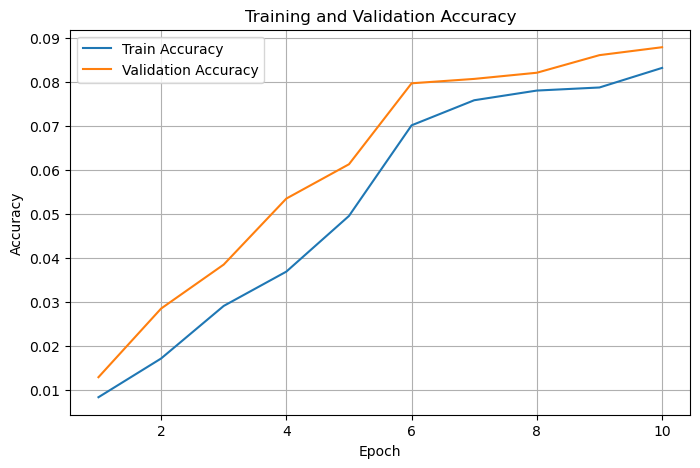

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_accs, label="Train Accuracy")
plt.plot(range(1, NUM_EPOCHS + 1), val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def calculate_top5_accuracy(model, dataloader, device):
    model.eval()

    top5_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            top5_predictions = outputs.topk(
                k=5,
                dim=1
            ).indices

            top5_correct += (
                top5_predictions == labels.unsqueeze(1)
            ).any(dim=1).sum().item()

            total += labels.size(0)

    return top5_correct / total


test_top5_acc = calculate_top5_accuracy(
    model,
    test_loader,
    device
)

print(f"Top-1 Accuracy : {test_acc:.4f}")
print(f"Top-5 Accuracy : {test_top5_acc:.4f}")

Top-1 Accuracy : 0.0880
Top-5 Accuracy : 0.2378


In [ ]:
start_time = time.time()

test_loss, test_acc, test_labels, test_preds = evaluate(
    model,
    test_loader,
    criterion,
    device
)

test_time = time.time() - start_time

print(f"Total test time: {test_time:.2f} seconds")
print(
    f"Average inference time per image: "
    f"{test_time / len(test_dataset):.6f} seconds"
)

Total test time: 21.48 seconds
Average inference time per image: 0.004296 seconds


In [ ]:
cm = confusion_matrix(
    test_labels,
    test_preds,
    labels=list(range(NUM_CLASSES))
)

print("Confusion matrix shape:", cm.shape)
print("Total evaluated samples:", cm.sum())

Confusion matrix shape: (500, 500)
Total evaluated samples: 5000
